<a href="https://colab.research.google.com/github/aswin-ar3669/RLA-Python-Learning/blob/main/RLA_Unit_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Episode: 100, Total Reward: -1, MSVE: 0.1640337006459254
Episode: 200, Total Reward: -3, MSVE: 0.09043487024482076
Episode: 300, Total Reward: 1, MSVE: 0.04160888053554172
Episode: 400, Total Reward: -8, MSVE: 0.08052898249048372
Episode: 500, Total Reward: -11, MSVE: 0.054175852420727144
Episode: 600, Total Reward: 0, MSVE: 0.011094763931205143
Episode: 700, Total Reward: -7, MSVE: 0.025373361601005066
Episode: 800, Total Reward: -1, MSVE: 0.008221557745965119
Episode: 900, Total Reward: 1, MSVE: 0.010660360991266972
Episode: 1000, Total Reward: -1, MSVE: 0.013494212528836457


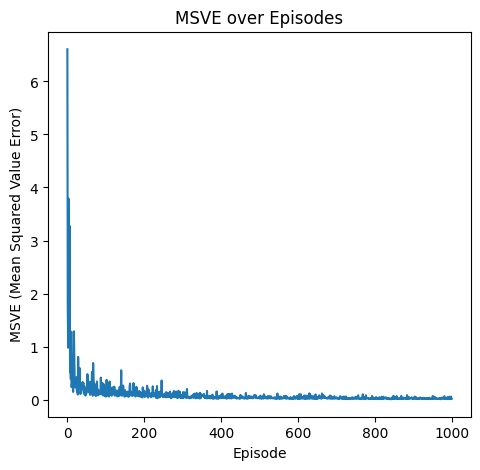

In [2]:
#1.	Stochastic-gradient Implementation
import numpy as np
import matplotlib.pyplot as plt

# Define a simple grid environment
class GridEnvironment:
    def __init__(self):
        self.grid = np.array([
            [0, 0, 0, 1],
            [0, -1, 0, -1],
            [0, 0, 0, 0]
        ])
        self.start_state = (2, 0)  # Starting position
        self.goal_state = (0, 3)   # Goal position
        self.current_state = self.start_state

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        if action == 0:  # Up
            x = max(x - 1, 0)
        elif action == 1:  # Down
            x = min(x + 1, self.grid.shape[0] - 1)
        elif action == 2:  # Left
            y = max(y - 1, 0)
        elif action == 3:  # Right
            y = min(y + 1, self.grid.shape[1] - 1)

        self.current_state = (x, y)
        reward = self.grid[x, y]
        done = (self.current_state == self.goal_state)
        return self.current_state, reward, done

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
episodes = 1000

# Initialize the environment
env = GridEnvironment()

# Feature construction: One-hot encoding of states
n_states = env.grid.shape[0] * env.grid.shape[1]
weights = np.zeros(n_states)  # Weight vector for value function approximation

# Function to transform state into feature vector
def get_features(state):
    x, y = state
    state_index = x * env.grid.shape[1] + y
    features = np.zeros(n_states)
    features[state_index] = 1
    return features

# Training the agent using Stochastic Gradient Descent
rewards = []
msve_values = []  # To store MSVE values

for episode in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    total_bellman_error = 0  # To accumulate Bellman error for MSVE

    while not done:
        # Choose a random action (for simplicity)
        action = np.random.randint(4)  # Random action (0: Up, 1: Down, 2: Left, 3: Right)
        next_state, reward, done = env.step(action)

        # Compute the target value
        target = reward + gamma * np.dot(weights, get_features(next_state))

        # Compute the current value
        current_value = np.dot(weights, get_features(state))

        # Compute the Bellman error
        bellman_error = target - current_value
        total_bellman_error += bellman_error ** 2  # Squared error for MSVE

        # Update weights using Stochastic Gradient Descent
        weights += alpha * bellman_error * get_features(state)

        # Move to the next state
        state = next_state
        total_reward += reward

    # Calculate MSVE for this episode
    msve = total_bellman_error / (episode + 1)  # Normalize by the number of steps
    msve_values.append(msve)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, MSVE: {msve}")

# Plot the rewards and MSVE
plt.figure(figsize=(12, 5))

# Plot MSVE
plt.subplot(1, 2, 2)
plt.plot(msve_values)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('MSVE over Episodes')
plt.show()


Episode: 100, Total Reward: 0, Epsilon: 0.6057704364907278, MSVE: 0.01610826723222928
Episode: 200, Total Reward: 1, Epsilon: 0.3669578217261671, MSVE: 0.002314822240214389
Episode: 300, Total Reward: 1, Epsilon: 0.22229219984074702, MSVE: 0.0024170224839370927
Episode: 400, Total Reward: 1, Epsilon: 0.1346580429260134, MSVE: 7.264383522155404e-05
Episode: 500, Total Reward: 1, Epsilon: 0.08157186144027828, MSVE: 0.0007876918984348349
Episode: 600, Total Reward: 1, Epsilon: 0.0494138221100385, MSVE: 1.1861190486699882e-05
Episode: 700, Total Reward: 1, Epsilon: 0.029933432588273214, MSVE: 5.025891029322624e-06
Episode: 800, Total Reward: 1, Epsilon: 0.018132788524664028, MSVE: 1.3393379940025449e-07
Episode: 900, Total Reward: 1, Epsilon: 0.01098430721937979, MSVE: 2.9787716946378137e-08
Episode: 1000, Total Reward: 1, Epsilon: 0.01, MSVE: 5.4468612441015637e-08


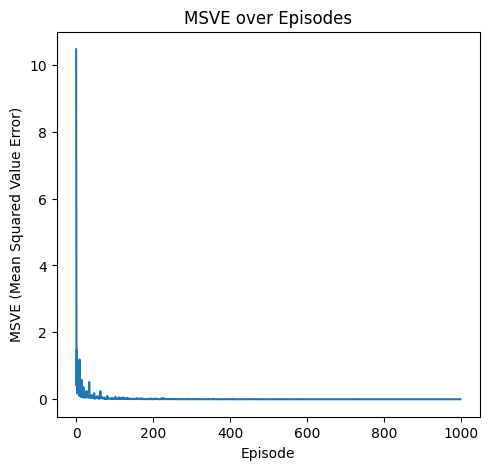

In [3]:
#2.	Semi-gradient Methods
import numpy as np
import matplotlib.pyplot as plt

# Define a simple grid environment
class GridEnvironment:
    def __init__(self):
        self.grid = np.array([
            [0, 0, 0, 1],
            [0, -1, 0, -1],
            [0, 0, 0, 0]
        ])
        self.start_state = (2, 0)  # Starting position
        self.goal_state = (0, 3)   # Goal position
        self.current_state = self.start_state

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        if action == 0:  # Up
            x = max(x - 1, 0)
        elif action == 1:  # Down
            x = min(x + 1, self.grid.shape[0] - 1)
        elif action == 2:  # Left
            y = max(y - 1, 0)
        elif action == 3:  # Right
            y = min(y + 1, self.grid.shape[1] - 1)

        self.current_state = (x, y)
        reward = self.grid[x, y]
        done = (self.current_state == self.goal_state)
        return self.current_state, reward, done

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = GridEnvironment()

# Feature construction: One-hot encoding of state-action pairs
n_states = env.grid.shape[0] * env.grid.shape[1]
n_actions = 4  # Up, Down, Left, Right
n_features = n_states * n_actions  # Number of features
weights = np.zeros(n_features)  # Weight vector for Q-value approximation

# Function to transform state-action pair into feature vector
def get_features(state, action):
    x, y = state
    state_index = x * env.grid.shape[1] + y
    features = np.zeros(n_features)
    features[state_index * n_actions + action] = 1
    return features

# Function to choose action using epsilon-greedy policy
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)  # Random action
    else:
        q_values = [np.dot(weights, get_features(state, a)) for a in range(n_actions)]
        return np.argmax(q_values)  # Greedy action

# Training the agent using Semi-gradient Descent
rewards = []
msve_values = []  # To store MSVE values

for episode in range(episodes):
    state = env.reset()
    action = choose_action(state, epsilon)

    total_reward = 0
    done = False
    total_bellman_error = 0  # To accumulate Bellman error for MSVE

    while not done:
        next_state, reward, done = env.step(action)
        next_action = choose_action(next_state, epsilon)

        # Compute the target Q-value
        target = reward + gamma * np.dot(weights, get_features(next_state, next_action))

        # Compute the current Q-value
        current_q = np.dot(weights, get_features(state, action))

        # Compute the Bellman error
        bellman_error = target - current_q
        total_bellman_error += bellman_error ** 2  # Squared error for MSVE

        # Update weights using Semi-gradient Descent
        weights += alpha * bellman_error * get_features(state, action)

        # Move to the next state
        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Calculate MSVE for this episode
    msve = total_bellman_error / (episode + 1)  # Normalize by the number of steps
    msve_values.append(msve)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, Epsilon: {epsilon}, MSVE: {msve}")

# Plot the rewards and MSVE
plt.figure(figsize=(12, 5))

# Plot MSVE
plt.subplot(1, 2, 2)
plt.plot(msve_values)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('MSVE over Episodes')
plt.show()


Episode: 100, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 200, SGD Reward: 0, Semi-gradient Reward: 0
Episode: 300, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 400, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 500, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 600, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 700, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 800, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 900, SGD Reward: 1, Semi-gradient Reward: 1
Episode: 1000, SGD Reward: 1, Semi-gradient Reward: 1


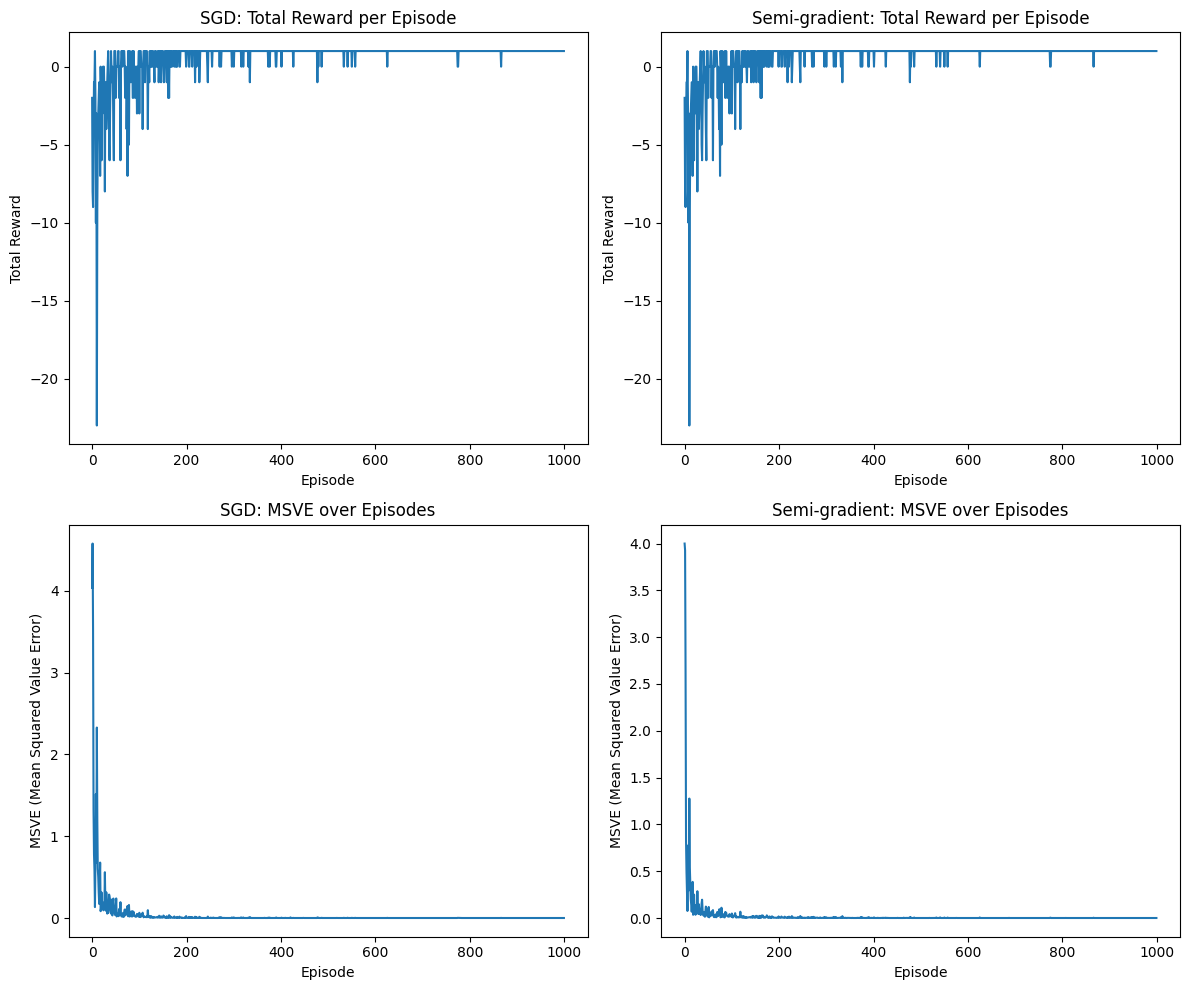

In [4]:
#3.	Linear Methods using Stochastic-gradient and Semi-gradient Methods
import numpy as np
import matplotlib.pyplot as plt

# Define a simple grid environment
class GridEnvironment:
    def __init__(self):
        self.grid = np.array([
            [0, 0, 0, 1],
            [0, -1, 0, -1],
            [0, 0, 0, 0]
        ])
        self.start_state = (2, 0)  # Starting position
        self.goal_state = (0, 3)   # Goal position
        self.current_state = self.start_state

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        if action == 0:  # Up
            x = max(x - 1, 0)
        elif action == 1:  # Down
            x = min(x + 1, self.grid.shape[0] - 1)
        elif action == 2:  # Left
            y = max(y - 1, 0)
        elif action == 3:  # Right
            y = min(y + 1, self.grid.shape[1] - 1)

        self.current_state = (x, y)
        reward = self.grid[x, y]
        done = (self.current_state == self.goal_state)
        return self.current_state, reward, done

# Hyperparameters
alpha_sgd = 0.1  # Learning rate for SGD
alpha_semi = 0.1  # Learning rate for Semi-gradient
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = GridEnvironment()

# Feature construction: One-hot encoding of states and state-action pairs
n_states = env.grid.shape[0] * env.grid.shape[1]
n_actions = 4  # Up, Down, Left, Right

# Initialize weights for SGD (value function approximation)
weights_sgd = np.zeros(n_states)

# Initialize weights for Semi-gradient (Q-value approximation)
weights_semi = np.zeros(n_states * n_actions)

# Function to transform state into feature vector (for SGD)
def get_features_sgd(state):
    x, y = state
    state_index = x * env.grid.shape[1] + y
    features = np.zeros(n_states)
    features[state_index] = 1
    return features

# Function to transform state-action pair into feature vector (for Semi-gradient)
def get_features_semi(state, action):
    x, y = state
    state_index = x * env.grid.shape[1] + y
    features = np.zeros(n_states * n_actions)
    features[state_index * n_actions + action] = 1
    return features

# Function to choose action using epsilon-greedy policy (for Semi-gradient)
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)  # Random action
    else:
        q_values = [np.dot(weights_semi, get_features_semi(state, a)) for a in range(n_actions)]
        return np.argmax(q_values)  # Greedy action

# Training the agent using both SGD and Semi-gradient Descent
rewards_sgd = []
rewards_semi = []
msve_sgd = []  # To store MSVE for SGD
msve_semi = []  # To store MSVE for Semi-gradient

for episode in range(episodes):
    state = env.reset()
    action = choose_action(state, epsilon)

    total_reward_sgd = 0
    total_reward_semi = 0
    done = False
    total_bellman_error_sgd = 0  # To accumulate Bellman error for SGD
    total_bellman_error_semi = 0  # To accumulate Bellman error for Semi-gradient

    while not done:
        # Take the action and observe the next state and reward
        next_state, reward, done = env.step(action)

        # === SGD for Value Function Approximation ===
        # Compute the target value
        target_sgd = reward + gamma * np.dot(weights_sgd, get_features_sgd(next_state))

        # Compute the current value
        current_value_sgd = np.dot(weights_sgd, get_features_sgd(state))

        # Compute the Bellman error
        bellman_error_sgd = target_sgd - current_value_sgd
        total_bellman_error_sgd += bellman_error_sgd ** 2  # Squared error for MSVE

        # Update weights using Stochastic Gradient Descent
        weights_sgd += alpha_sgd * bellman_error_sgd * get_features_sgd(state)

        # === Semi-gradient for Q-value Approximation ===
        next_action = choose_action(next_state, epsilon)

        # Compute the target Q-value
        target_semi = reward + gamma * np.dot(weights_semi, get_features_semi(next_state, next_action))

        # Compute the current Q-value
        current_q_semi = np.dot(weights_semi, get_features_semi(state, action))

        # Compute the Bellman error
        bellman_error_semi = target_semi - current_q_semi
        total_bellman_error_semi += bellman_error_semi ** 2  # Squared error for MSVE

        # Update weights using Semi-gradient Descent
        weights_semi += alpha_semi * bellman_error_semi * get_features_semi(state, action)

        # Move to the next state
        state = next_state
        action = next_action
        total_reward_sgd += reward
        total_reward_semi += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Calculate MSVE for this episode
    msve_sgd.append(total_bellman_error_sgd / (episode + 1))
    msve_semi.append(total_bellman_error_semi / (episode + 1))

    rewards_sgd.append(total_reward_sgd)
    rewards_semi.append(total_reward_semi)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, SGD Reward: {total_reward_sgd}, Semi-gradient Reward: {total_reward_semi}")

# Plot the rewards and MSVE
plt.figure(figsize=(12, 10))

# Plot total rewards
plt.subplot(2, 2, 1)
plt.plot(rewards_sgd)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('SGD: Total Reward per Episode')

plt.subplot(2, 2, 2)
plt.plot(rewards_semi)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Semi-gradient: Total Reward per Episode')

# Plot MSVE
plt.subplot(2, 2, 3)
plt.plot(msve_sgd)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('SGD: MSVE over Episodes')

plt.subplot(2, 2, 4)
plt.plot(msve_semi)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('Semi-gradient: MSVE over Episodes')

plt.tight_layout()
plt.show()


Episode: 100, Total Reward: 1, Epsilon: 0.6057704364907278, MSVE: 0.007738900900524721
Episode: 200, Total Reward: 1, Epsilon: 0.3669578217261671, MSVE: 8.623403650355027e-05
Episode: 300, Total Reward: 1, Epsilon: 0.22229219984074702, MSVE: 2.6147502404339444e-07
Episode: 400, Total Reward: 1, Epsilon: 0.1346580429260134, MSVE: 2.1778831181957555e-08
Episode: 500, Total Reward: 1, Epsilon: 0.08157186144027828, MSVE: 1.0284358899534863e-09
Episode: 600, Total Reward: 1, Epsilon: 0.0494138221100385, MSVE: 1.0148399042980517e-09
Episode: 700, Total Reward: 1, Epsilon: 0.029933432588273214, MSVE: 4.574259341094644e-15
Episode: 800, Total Reward: 1, Epsilon: 0.018132788524664028, MSVE: 5.601719460571246e-08
Episode: 900, Total Reward: 1, Epsilon: 0.01098430721937979, MSVE: 2.442144353201844e-10
Episode: 1000, Total Reward: 1, Epsilon: 0.01, MSVE: 1.3058135661673354e-09


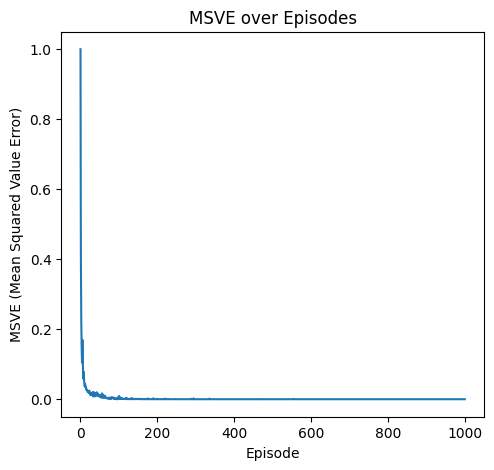

State: (0, 1), Action: 3, Reward: 0
State: (1, 1), Action: 1, Reward: 1
Total Reward during testing: 1


In [5]:
#4.	Semi-gradient n-step Sarsa
import numpy as np
import matplotlib.pyplot as plt

# Define a simple grid world environment
class GridWorld:
    def __init__(self):
        self.states = [(0, 0), (0, 1), (1, 0), (1, 1)]  # 2x2 grid
        self.actions = [0, 1, 2, 3]  # Up, Down, Left, Right
        self.goal = (1, 1)  # Goal state
        self.current_state = (0, 0)  # Start state

    def reset(self):
        self.current_state = (0, 0)
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        if action == 0:  # Up
            x = max(x - 1, 0)
        elif action == 1:  # Down
            x = min(x + 1, 1)
        elif action == 2:  # Left
            y = max(y - 1, 0)
        elif action == 3:  # Right
            y = min(y + 1, 1)

        self.current_state = (x, y)
        reward = 1 if self.current_state == self.goal else 0
        done = self.current_state == self.goal
        return self.current_state, reward, done

# Hyperparameters
alpha = 0.1  # Learning rate for weights
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = GridWorld()

# Initialize weights for the linear function approximator
n_features = len(env.states) * len(env.actions)  # Number of features
weights = np.zeros(n_features)

# Function to transform state-action pair into feature vector
def get_features(state, action):
    feature_vector = np.zeros(n_features)
    index = env.states.index(state) * len(env.actions) + action
    feature_vector[index] = 1  # One-hot encoding
    return feature_vector

# Function to choose action using epsilon-greedy policy
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(env.actions)  # Random action
    else:
        q_values = [np.dot(weights, get_features(state, a)) for a in env.actions]
        return np.argmax(q_values)  # Greedy action

# Training the agent using Episodic Semi-gradient Control
rewards = []
msve_values = []  # To store MSVE values

for episode in range(episodes):
    state = env.reset()
    action = choose_action(state, epsilon)

    total_reward = 0
    done = False
    total_bellman_error = 0  # To accumulate Bellman error for MSVE

    while not done:
        next_state, reward, done = env.step(action)
        next_action = choose_action(next_state, epsilon)

        # Compute the target Q-value
        target = reward + gamma * np.dot(weights, get_features(next_state, next_action))

        # Compute the current Q-value
        current_q = np.dot(weights, get_features(state, action))

        # Compute the Bellman error
        bellman_error = target - current_q
        total_bellman_error += bellman_error ** 2  # Squared error for MSVE

        # Update weights using semi-gradient SARSA
        weights += alpha * bellman_error * get_features(state, action)

        # Move to the next state
        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Calculate MSVE for this episode
    msve = total_bellman_error / (episode + 1)  # Normalize by the number of steps
    msve_values.append(msve)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, Epsilon: {epsilon}, MSVE: {msve}")

# Plot the rewards and MSVE
plt.figure(figsize=(12, 5))

# Plot MSVE
plt.subplot(1, 2, 2)
plt.plot(msve_values)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('MSVE over Episodes')
plt.show()

# Test the trained agent
state = env.reset()
done = False
total_reward = 0

while not done:
    action = choose_action(state, epsilon_min)  # Use epsilon_min for testing (greedy policy)
    next_state, reward, done = env.step(action)
    state = next_state
    total_reward += reward
    print(f"State: {state}, Action: {action}, Reward: {reward}")

print(f"Total Reward during testing: {total_reward}")


Episode: 100, Total Reward: -2, Epsilon: 0.6057704364907278, MSVE: 0.025661061991933853
Episode: 200, Total Reward: 1, Epsilon: 0.3669578217261671, MSVE: 0.0018749866748696631
Episode: 300, Total Reward: 1, Epsilon: 0.22229219984074702, MSVE: 0.00047352811311086754
Episode: 400, Total Reward: 1, Epsilon: 0.1346580429260134, MSVE: 0.00020378149772988977
Episode: 500, Total Reward: 1, Epsilon: 0.08157186144027828, MSVE: 8.72531799707486e-05
Episode: 600, Total Reward: 1, Epsilon: 0.0494138221100385, MSVE: 4.014504985014981e-05
Episode: 700, Total Reward: 1, Epsilon: 0.029933432588273214, MSVE: 3.208573858398359e-05
Episode: 800, Total Reward: 1, Epsilon: 0.018132788524664028, MSVE: 0.00013586897770288817
Episode: 900, Total Reward: 1, Epsilon: 0.01098430721937979, MSVE: 4.582021014273308e-06
Episode: 1000, Total Reward: 1, Epsilon: 0.01, MSVE: 1.4938639923993939e-06


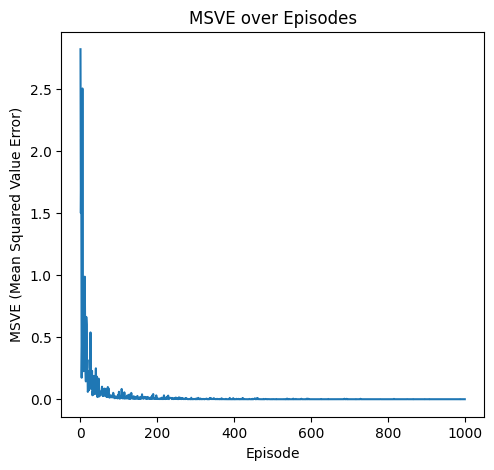

State: (2, 1), Action: 3, Reward: 0
State: (2, 2), Action: 3, Reward: 0
State: (1, 2), Action: 0, Reward: 0
State: (0, 2), Action: 0, Reward: 0
State: (0, 3), Action: 3, Reward: 1
Total Reward during testing: 1


In [6]:
#5.	Semi-Gradient SARSA
import numpy as np
import matplotlib.pyplot as plt

# Define a simple grid environment
class GridEnvironment:
    def __init__(self):
        self.grid = np.array([
            [0, 0, 0, 1],
            [0, -1, 0, -1],
            [0, 0, 0, 0]
        ])
        self.start_state = (2, 0)  # Starting position
        self.goal_state = (0, 3)   # Goal position
        self.current_state = self.start_state
        self.n_actions = 4  # Up, Down, Left, Right

    def reset(self):
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        x, y = self.current_state
        if action == 0:  # Up
            x = max(x - 1, 0)
        elif action == 1:  # Down
            x = min(x + 1, self.grid.shape[0] - 1)
        elif action == 2:  # Left
            y = max(y - 1, 0)
        elif action == 3:  # Right
            y = min(y + 1, self.grid.shape[1] - 1)

        self.current_state = (x, y)
        reward = self.grid[x, y]
        done = (self.current_state == self.goal_state)
        return self.current_state, reward, done

# Hyperparameters
alpha = 0.1  # Learning rate for weights
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = GridEnvironment()

# Feature construction: One-hot encoding of states
n_states = env.grid.shape[0] * env.grid.shape[1]
n_features = n_states * env.n_actions  # Number of features
weights = np.zeros(n_features)

# Function to transform state into feature vector
def get_features(state, action):
    x, y = state
    state_index = x * env.grid.shape[1] + y
    features = np.zeros(n_features)
    features[state_index * env.n_actions + action] = 1
    return features

# Function to choose action using epsilon-greedy policy
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(env.n_actions)  # Random action
    else:
        q_values = [np.dot(weights, get_features(state, a)) for a in range(env.n_actions)]
        return np.argmax(q_values)  # Greedy action

# Training the agent using n-Episodic Semi-gradient Control
rewards = []
msve_values = []  # To store MSVE values

for episode in range(episodes):
    state = env.reset()
    action = choose_action(state, epsilon)

    total_reward = 0
    done = False
    total_bellman_error = 0  # To accumulate Bellman error for MSVE

    while not done:
        next_state, reward, done = env.step(action)
        next_action = choose_action(next_state, epsilon)

        # Compute the target Q-value
        target = reward + gamma * np.dot(weights, get_features(next_state, next_action))

        # Compute the current Q-value
        current_q = np.dot(weights, get_features(state, action))

        # Compute the Bellman error
        bellman_error = target - current_q
        total_bellman_error += bellman_error ** 2  # Squared error for MSVE

        # Update weights using semi-gradient SARSA
        weights += alpha * bellman_error * get_features(state, action)

        # Move to the next state
        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Calculate MSVE for this episode
    msve = total_bellman_error / (episode + 1)  # Normalize by the number of steps
    msve_values.append(msve)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, Epsilon: {epsilon}, MSVE: {msve}")

# Plot the rewards and MSVE
plt.figure(figsize=(12, 5))

# Plot MSVE
plt.subplot(1, 2, 2)
plt.plot(msve_values)
plt.xlabel('Episode')
plt.ylabel('MSVE (Mean Squared Value Error)')
plt.title('MSVE over Episodes')
plt.show()

# Test the trained agent
state = env.reset()
done = False
total_reward = 0

while not done:
    action = choose_action(state, epsilon_min)  # Use epsilon_min for testing (greedy policy)
    next_state, reward, done = env.step(action)
    state = next_state
    total_reward += reward
    print(f"State: {state}, Action: {action}, Reward: {reward}")

print(f"Total Reward during testing: {total_reward}")


Intermediate returns: [1.54, 2.4669999999999996, 3.2932, 3.439]


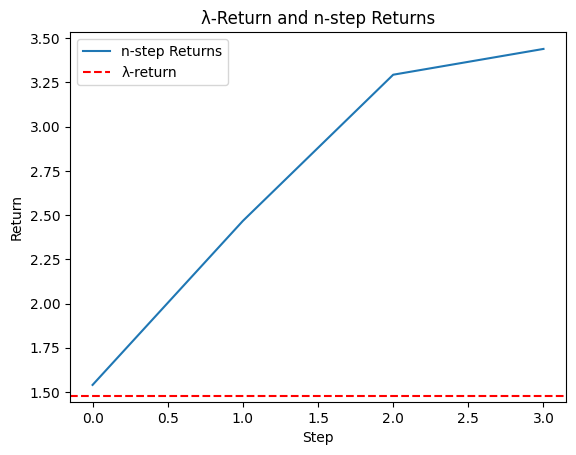

1.4764031999999998

In [1]:
#7.	λ-Return
import numpy as np
import matplotlib.pyplot as plt

def lambda_return(rewards, values, gamma, lambd):
    """
    Compute the λ-return for a given trajectory with debugging information.
    """
    T = len(rewards)
    g_lambda = 0
    returns = []  # To store intermediate returns for plotting
    for n in range(1, T + 1):
        n_step_return = sum(gamma**k * rewards[k] for k in range(n))
        if n < T:
            n_step_return += gamma**n * values[n]
        g_lambda += (lambd**(n - 1)) * n_step_return
        returns.append(n_step_return)  # Store the n-step return
    g_lambda *= (1 - lambd)

    print(f"Intermediate returns: {returns}")
    plt.plot(returns, label="n-step Returns")
    plt.axhline(y=g_lambda, color='r', linestyle='--', label="λ-return")
    plt.xlabel("Step")
    plt.ylabel("Return")
    plt.legend()
    plt.title("λ-Return and n-step Returns")
    plt.show()

    return g_lambda

# Example
rewards = [1, 1, 1, 1]
values = [0.5, 0.6, 0.7, 0.8]
lambda_return(rewards, values, gamma=0.9, lambd=0.8)


In [3]:
#6.	Episodic SARSA in mountain car
import gym
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = gym.make('MountainCar-v0')

# Discretize the state space
num_states = 20
state_space = [np.linspace(-1.2, 0.6, num_states),
               np.linspace(-0.07, 0.07, num_states)]

# Initialize Q-table
Q = np.zeros((num_states, num_states, env.action_space.n))

# Function to discretize the state
def discretize_state(state):
    discretized_state = []
    for i in range(len(state)):
        discretized_state.append(np.digitize(state[i], state_space[i]) - 1)
    return tuple(discretized_state)

# Training the agent using Episodic SARSA
rewards = []
for episode in range(episodes):
    # Extract the observation from the dictionary returned by env.reset()
    state = discretize_state(env.reset()[0])  # Use [0] to get the observation
    action = np.argmax(Q[state])
    if np.random.rand() < epsilon:
        action = env.action_space.sample()

    total_reward = 0
    done = False

    while not done:
        next_state, reward, done, _, _ = env.step(action)  # Updated to match gym v0.26+
        next_state = discretize_state(next_state)

        # Choose next action using epsilon-greedy policy
        next_action = np.argmax(Q[next_state])
        if np.random.rand() < epsilon:
            next_action = env.action_space.sample()

        # Update Q-value using SARSA update rule
        Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, Epsilon: {epsilon}")

# Plot the rewards
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Episodic SARSA on MountainCar-v0')
plt.show()

# Test the trained agent
state = discretize_state(env.reset()[0])  # Use [0] to get the observation
done = False
total_reward = 0

while not done:
    action = np.argmax(Q[state])
    next_state, reward, done, _, _ = env.step(action)  # Updated to match gym v0.26+
    state = discretize_state(next_state)
    total_reward += reward
    env.render()

print(f"Total Reward during testing: {total_reward}")

env.close()


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


TypeError: object of type 'numpy.float32' has no len()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode: 100, Total Reward: -200.0, Epsilon: 0.6057704364907278
Episode: 200, Total Reward: -200.0, Epsilon: 0.3669578217261671
Episode: 300, Total Reward: -200.0, Epsilon: 0.22229219984074702
Episode: 400, Total Reward: -200.0, Epsilon: 0.1346580429260134
Episode: 500, Total Reward: -200.0, Epsilon: 0.08157186144027828
Episode: 600, Total Reward: -198.0, Epsilon: 0.0494138221100385
Episode: 700, Total Reward: -200.0, Epsilon: 0.029933432588273214
Episode: 800, Total Reward: -200.0, Epsilon: 0.018132788524664028
Episode: 900, Total Reward: -192.0, Epsilon: 0.01098430721937979
Episode: 1000, Total Reward: -200.0, Epsilon: 0.01


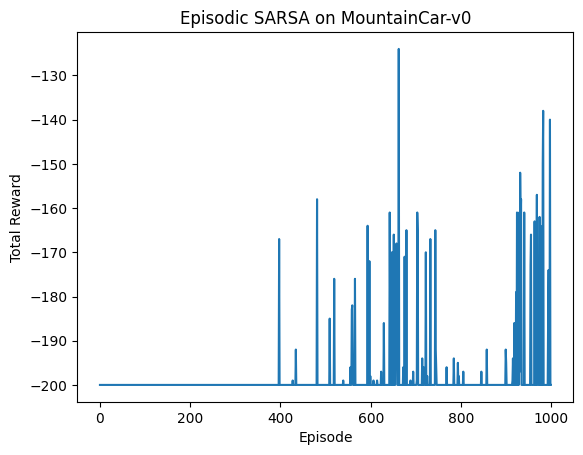

Total Reward during testing: -168.0


In [8]:
#6. Episodic SARSA in mountain car
import gym
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000

# Initialize the environment
env = gym.make('MountainCar-v0')

# Discretize the state space
num_states = 20
state_space = [np.linspace(-1.2, 0.6, num_states),
               np.linspace(-0.07, 0.07, num_states)]

# Initialize Q-table
Q = np.zeros((num_states, num_states, env.action_space.n))

# Function to discretize the state
def discretize_state(state_observation):
    # Check if the observation is a scalar (e.g., numpy.float32) instead of an array
    if not isinstance(state_observation, (np.ndarray, list, tuple)):
        # For MountainCar-v0, the state is typically [position, velocity].
        # At reset, velocity is usually 0.0. We create a 2-element array.
        state_observation = np.array([state_observation, 0.0])

    discretized_state = []
    for i in range(len(state_observation)):
        discretized_state.append(np.digitize(state_observation[i], state_space[i]) - 1)
    return tuple(discretized_state)

# Training the agent using Episodic SARSA
rewards = []
for episode in range(episodes):
    # Extract the observation from the dictionary returned by env.reset()
    # Use the modified discretize_state function which handles scalar observations
    state = discretize_state(env.reset()[0])  # Use [0] to get the observation
    action = np.argmax(Q[state])
    if np.random.rand() < epsilon:
        action = env.action_space.sample()

    total_reward = 0
    done = False

    while not done:
        next_state_raw, reward, done, _ = env.step(action)  # Modified to unpack 4 values
        next_state = discretize_state(next_state_raw)

        # Choose next action using epsilon-greedy policy
        next_action = np.argmax(Q[next_state])
        if np.random.rand() < epsilon:
            next_action = env.action_space.sample()

        # Update Q-value using SARSA update rule
        Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards.append(total_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_reward}, Epsilon: {epsilon}")

# Plot the rewards
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Episodic SARSA on MountainCar-v0')
plt.show()

# Test the trained agent
state = discretize_state(env.reset()[0])  # Use [0] to get the observation
done = False
total_reward = 0

while not done:
    action = np.argmax(Q[state])
    next_state_raw, reward, done, _ = env.step(action)  # Modified to unpack 4 values
    state = discretize_state(next_state_raw)
    total_reward += reward
    env.render()

print(f"Total Reward during testing: {total_reward}")

env.close()